# Pareto Smoothed Importance Sampling (PSIS) of Field Level Inference Chain Data

## Stage 1: Running PSIS on Individual Voxels

Pareto Smoothed Importance Sampling is first run on a small subset of the data to verify it is well behaved with regards to the data structure. 

Individual voxels have been pulled out of the larger data set in order to be examined in this manner.

The files labelled "test_delta_logdensity_i_j_k.npy" have a small subset of data from only the ith,jth,kth voxel as opposed to the full voxel grid.

In [1]:
using Pkg
Pkg.activate(".")

  Activating new project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data`


In [3]:
Pkg.add("NPZ")
Pkg.add("PSIS")
Pkg.add("Plots")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data/Project.toml`
  [15e1cf62] + NPZ v0.4.3
    Updating `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data/Manifest.toml`
  [5789e2e9] + FileIO v1.18.0
  [15e1cf62] + NPZ v0.4.3
  [ae029012] + Requires v1.3.1
  [a5390f91] + ZipFile v0.10.1
  [0dad84c5] + ArgTools v1.1.2
  [56f22d72] + Artifacts v1.11.0
  [2a0f44e3] + Base64 v1.11.0
  [ade2ca70] + Dates v1.11.0
  [f43a241f] + Downloads v1.6.0
  [7b1f6079] + FileWatching v1.11.0
  [b27032c2] + LibCURL v0.6.4
  [76f85450] + LibGit2 v1.11.0
  [8f399da3] + Libdl v1.11.0
  [56ddb016] + Logging v1.11.0
  [d6f4376e] + Markdown v1.11.0
  [ca575930] + NetworkOptions v1.2.0
  [44cfe95a] + Pkg v1.11.0
  [de0858da] + Printf v1.11.0
  [9a3f8284] + Random v1.11.0
  [ea8e919c] + SHA v0.7.0
  [fa267f1f] + TOML v1.0.3
  [a4e569a6] + Tar v1.10.0
  [cf7118a7] + UUIDs v1.11.0
  [4ec0a83e

In [4]:
using NPZ
using PSIS
using Plots

The 0, 0, 0th voxel's data is read out of the .npy file 

In [5]:
x = npzread("lpt_32_eh1_ovsamp1/test_delta_logdensity_0_0_0.npy")

SystemError: SystemError: opening file "lpt_32_eh1_ovsamp1/test_delta_logdensity_0_0_0.npy": No such file or directory

The file contains 4 chains, each having 256 values of the sampled delta_logdensity.

All of the delta log-densities are put into a single data vector for the full voxel data

In [4]:
delta_logdensities = vec(x)

1024-element Vector{Float64}:
 4.073278306345878
 4.049749615783295
 4.1884264850391455
 4.11782297683475
 4.003108819391245
 4.457899353119483
 3.8901096019349652
 5.718950186759965
 4.452304488399489
 5.099515656958536
 ⋮
 4.022877156501282
 3.936003536653268
 3.987467549652958
 4.102866499230904
 5.665818974719574
 4.09871035894019
 4.103293990898524
 4.12828133640943
 4.85033733476817

The PSIS function takes the log ratios of the target and proposal distribution as an arguement. 

It can be shown mathematically that using the log ratios is equivalent to using the negative log densities as the arguement of the function

In [5]:
y = psis(-delta_logdensities)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  882

We can see the resulting importance weights that are calculated by PSIS for the voxel

In [6]:
y.weights

1024-element Vector{Float64}:
 0.0011484603148509023
 0.00117580248356381
 0.0010235469631896435
 0.0010984252005440832
 0.0012319418639049088
 0.0007817667488018326
 0.001379320370985219
 0.00022151838476174276
 0.0007861528864860411
 0.00041155394991339186
 ⋮
 0.0012078275570049173
 0.0013174485617378877
 0.0012513624845479283
 0.0011149772440381125
 0.00023360620176725498
 0.001119620889020961
 0.0011145007024227428
 0.001086997337344357
 0.0005280116982378128

The delta log-densities and weights can be visualized in a few different ways

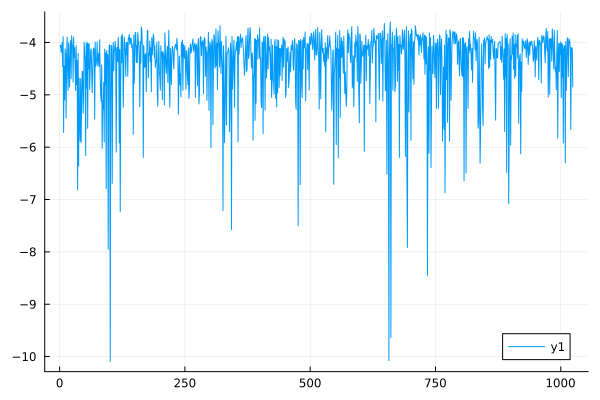

In [7]:
plot(-delta_logdensities)

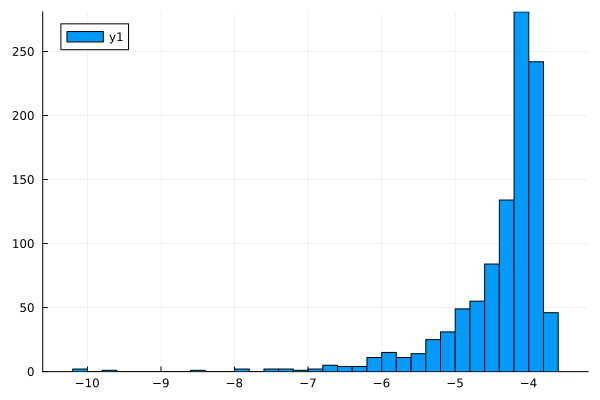

In [8]:
histogram(-delta_logdensities)

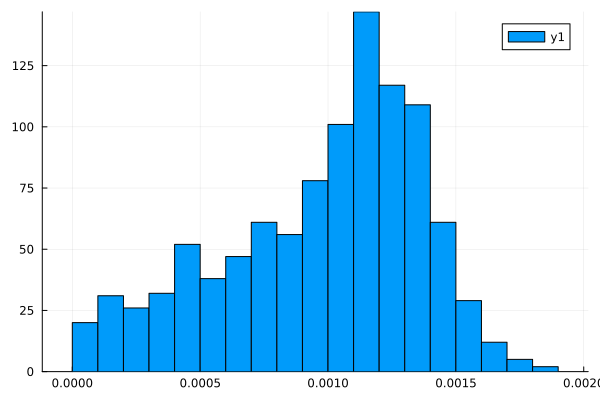

In [9]:
histogram(y.weights)

The process above for the 0, 0, 0th voxel is now repeated independently for 7 other voxels that were independently pulled out of the full data set in order to be tested upon. 

Each file is opened, read, and the data is put into a single vector of delta log-densities. These log-densities are then passed to the PSIS function as a negative arguement as shown above. 

In [10]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_0_0_16.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  876

In [11]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_0_16_0.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  905

In [12]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_0_16_16.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  870

In [13]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_16_0_0.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  879

In [14]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_16_0_16.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  870

In [15]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_16_16_0.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  881

In [16]:
x = vec(npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_delta_logdensity_16_16_16.npy"))
y = psis(-x)

PSISResult with 1024 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  881

As can be seen, for the 8 individual voxels that were removed, PSIS performs well on the subset of it's data that has been set aside. 

Each voxel returns a diagnostic value of k < 0.5 and the effective sample size (ESS) of the 1024 chain samples for each voxel is ~900. Note that this ESS is only the importance sampling ESS from PSIS, which only accounts for the weights. This is seperate from the MCMC ESS which accounts for the correlation of the chain.

The diagnostic value is the pareto shape parameter, which diagnoses the reliability and convergence of estimates using the importance weights. Specifically, k < 0.5 indicates that PSIS is stable and reliable, with finite variance.

# Stage 2: Running PSIS on the Full Chain Data for Full Voxel Grid

## Test File 1 Only

We begin by reading the first test file only. THis is 1 of 8 files. Each file contains a specific subset of the chain (in case of error later in running, each file can serve as a benchmark), but contains that subset of data for every voxel in the voxel grid. 

The first file is read alone in order to examine the data structure of the full voxel grid and how data is stored

In [18]:
x = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_with_delta_logdensity_1.npz")

Dict{String, Array{Float64}} with 12 entries:
  "sigma_delta_"     => [-5.54569 -8.14349 … -3.08195 -3.21208; -3.24658 -3.545…
  "delta_logdensity" => [4.06961 4.00475 … 3.9333 4.09358; 4.04337 4.47373 … 3.…
  "bs2_"             => [5.90593 2.63669 … 3.05455 2.20421; 4.35411 6.40152 … 4…
  "n_evals"          => [128.0 128.0 … 128.0 128.0; 128.0 128.0 … 128.0 128.0; …
  "sigma_0_"         => [7.32838 6.68079 … 5.49941 6.16135; 3.60744 5.13712 … 4…
  "ngbars_"          => [-0.573705 -0.638882 … 0.108464 -0.005616; -0.364082 -0…
  "logdensity"       => [-2.44378e5 -2.44289e5 … -2.42482e5 -2.43582e5; -2.4005…
  "init_mesh_"       => [-2.39885 0.911602 … -1.17294 1.04165; 0.20935 -2.12978…
  "b1_"              => [1.48338 1.22232 … 1.79489 1.06108; 2.17415 1.5503 … 1.…
  "b2_"              => [0.793201 1.05119 … 0.304136 0.0286908; 0.31101 -0.3854…
  "mse_per_dim"      => [1.64908e-7 1.86027e-7 … 6.34705e-8 9.16696e-8; 1.01538…
  "bn2_"             => [7.1227 5.69999 … 10.1285 3.87471; 9.99

The delta log-densities are extracted into their own variable. It can be seen below that the voxel grid is made up of 32 x 32 x 32 voxels, and that for each voxel, as before, there are 4 chains of 256 elements.

In [39]:
delta_logdensities = x["delta_logdensity"]

4×256×32×32×32 Array{Float64, 5}:
[:, :, 1, 1, 1] =
 4.01685  5.12882  4.05527  5.8308   …  4.08639  4.03016  4.06166  3.93294
 4.14514  5.56452  5.30417  3.91063     3.89789  3.99915  3.87928  3.92614
 4.98695  4.64683  4.039    4.21566     3.84395  3.84998  3.88852  3.99917
 4.12913  4.06197  3.79487  4.082       4.08029  3.74483  4.45486  5.71259

[:, :, 2, 1, 1] =
 3.87809  3.88714  3.86043  3.74871  …  6.86296  4.66118  3.92823  3.87726
 5.98804  4.44126  4.33538  5.95431     6.6246   4.13897  4.44449  3.99588
 4.37526  4.03918  4.39215  4.13236     3.85675  3.80924  3.81493  3.75924
 3.86546  3.9895   3.78189  3.7963      3.69975  3.67104  3.97115  3.77628

[:, :, 3, 1, 1] =
 4.02584  4.64141  4.33414  3.95305  …  4.09295  5.20262  4.70276  6.55446
 6.93764  6.63448  5.08716  4.17569     6.10291  6.21177  5.95123  4.69937
 4.82645  4.20194  4.22114  4.47982     4.53236  4.89905  3.9857   4.3147
 4.09567  4.60325  4.48237  4.16724     5.68201  4.15292  3.97812  4.21383

;;; … 

[:

The data is put into a 32 x 32 x 32 array where each element of the array represents one voxel of the grid. For each voxel, the four chains are put into a single data vector of all the log-densities of that particular voxel. 

In [20]:
voxel_data = Array{Vector{Float64}}(undef, 32, 32, 32)

for i in 1:32, j in 1:32, k in 1:32
    voxel_data[i, j, k] = vec(delta_logdensities[:, :, i, j, k])
end

In [21]:
voxel_data[29,4,15]

1024-element Vector{Float64}:
 4.154016416795468
 4.177628330736194
 3.8440352279535572
 4.753340754312172
 4.093731924247697
 3.9468234447114745
 4.276629889858932
 4.514771538409344
 3.983971502833056
 4.340637829517219
 ⋮
 8.11461813385857
 4.316300464267391
 4.051750546282996
 6.473838567830496
 5.3242472699901535
 4.147823103296804
 3.9679119170982906
 4.540633595920632
 4.5292594262920645

## Stage 3: Processing All Test Files Into Voxels

Initialize a 32x32x32 array of empty vectors where each element is a voxel

In [22]:
full_voxel_data = Array{Vector{Float64}}(undef, 32, 32, 32)

for i in 1:32, j in 1:32, k in 1:32
    full_voxel_data[i,j,k] = []
end


Instead of a single file, we read all 8 data files.
For each file, we follow a similar process to above, taking the voxel information for each voxel and creating a vector that stores all of the chains as a single object. This vector is then appended to the corresponding element of the array for that voxel, adding it to the data that has already been read for that voxel from previous files.

In [23]:
for file in 1:8

    x = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_with_delta_logdensity_$(file).npz")
    delta_logdensities = x["delta_logdensity"]

    for i in 1:32, j in 1:32, k in 1:32
        full_voxel_data[i, j, k] = append!(full_voxel_data[i, j, k], vec(delta_logdensities[:, :, i, j, k]))
    end
    
end

In [24]:
full_voxel_data[32, 1, 15]

8192-element Vector{Float64}:
 6.251168985497844
 6.730864260968075
 3.9247450444801464
 4.254162974014748
 4.358984984608116
 5.3006060019394825
 4.204893332280192
 4.6581570441885685
 4.758581050486183
 4.461919407348668
 ⋮
 3.9851107186707537
 5.701069823456387
 4.642109317000103
 3.9038170120078615
 5.435605904748782
 4.583631164328761
 4.310849536389444
 4.141049764716396
 4.164173631636293

Initialize a 32 x 32 x 32 array where each element will store the result of running PSIS on the corresponding voxel

In [40]:
psis_result = Array{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, 32, 32, 32);

Run PSIS for each voxel individually, using it's data vector of delta log-densities.

In [26]:
for i in 1:32, j in 1:32, k in 1:32
    psis_result[i, j, k] = psis(-full_voxel_data[i,j,k])
end

In [27]:
psis_result[24,17,5]

PSISResult with 8192 draws, 1 chains, and 1 parameters
Pareto shape (k) diagnostic values:
                    Count       Min. ESS
 (-Inf, 0.5]  good  1 (100.0%)  7134

Similarly, we initialize a 32 x 32 x 32 array to store the importance weights that result for each voxel from the PSIS process

In [29]:
psis_weights = Array{Vector{Float64}}(undef, 32, 32, 32)

for i in 1:32, j in 1:32, k in 1:32
    psis_weights[i,j,k] = psis_result[i,j,k].weights
end

In [30]:
psis_weights[1,1,1]

8192-element Vector{Float64}:
 0.00014837903168655786
 0.00015232332098565103
 0.00013282866025291098
 0.00013940178541081453
 0.0001583217614583342
 9.905210286785204e-5
 0.00017665658161006742
 2.7426949690534666e-5
 0.00010192829456780989
 5.174386903525406e-5
 ⋮
 0.00020571583638863107
 0.00014956263367579774
 0.0001794861715510943
 0.00017783517090224575
 0.00010093858063393242
 0.0001701088722094342
 0.00017126964517455838
 0.00015920687190179903
 2.869685342144685e-5

In [31]:
sum(psis_weights[27,1,15])

1.0000000000000002

These results are visualized both in order of sampling (i.e. their index in the chain) as well as a frequency histogram

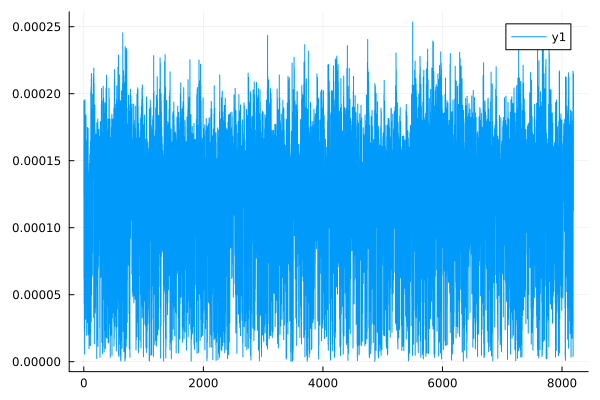

In [32]:
plot(psis_weights[30,24,7])

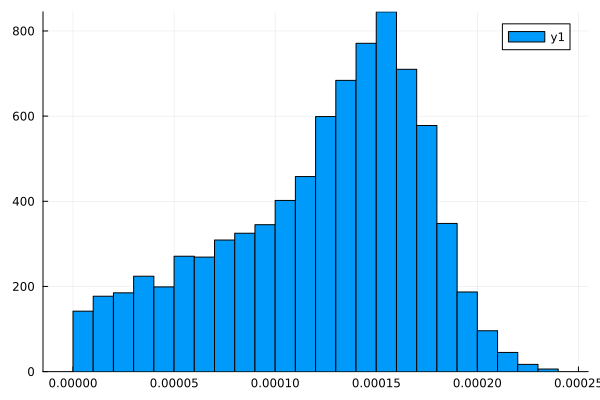

In [33]:
histogram(psis_weights[1,2,15])

The pareto shape parameters that diagnoses the reliability and convergence of estimates are stored in their own 32 x 32 x 32 array, and plotted below. It is seen that the pareto shape parameter is well below the value of 0.5 as is desired, indicating successful PSIS. 

In [34]:
pareto_shapes = []

for i in 1:32, j in 1:32, k in 1:32
    pareto_shapes = append!(pareto_shapes, psis_result[i,j,k].pareto_shape)
end
pareto_shapes

32768-element Vector{Any}:
 -0.16697065496139063
 -0.15887841927663582
 -0.133641525113157
 -0.1895495840379323
 -0.17819229306570825
 -0.11745638605748364
 -0.15324569164053434
 -0.22811778045314626
 -0.250522757784497
 -0.172929359503829
  ⋮
 -0.11993905323608785
  0.0705176765604305
 -0.13399781369736224
 -0.1869993448520659
 -0.04499067011387329
 -0.20537796123452134
 -0.17668682964025825
 -0.20514658664174754
 -0.12441903070279657

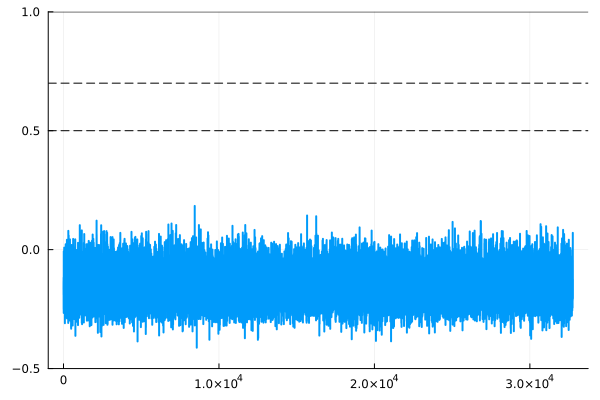

In [64]:
plot(vec(pareto_shapes), y = 0.5, ylims=(-0.5, 1), showlines=true, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dash, color=:black)
hline!([1], linestyle=:solid, color=:black)